# Clustering
---

In [80]:
import pandas as pd

In [81]:
user_features = pd.read_csv("data/data_preprocessed/user_features_grouped1.csv")

In [82]:
user_features["group"].value_counts()

group
Not assigned        3340
Indecisive          1373
Long Stayers         481
High Spenders        476
Discount buyer       102
Family travelers      76
Retired               63
Youngs                52
Only Hotel            25
Only Flight           10
Name: count, dtype: int64

In [83]:
df_raw = user_features[user_features["group"] == "Not assigned"]

In [84]:
df.isna().sum()

gender                   0
married                  0
has_children             0
age                      0
num_session              0
num_trips                0
num_flights              0
num_hotels               0
booking_discount_rate    0
average_seats            0
average_checked_bags     0
average_seat_price       0
weekend_trip_ratio       0
average_nights           0
total_flight_cost        0
total_hotels_cost        0
conversion_rate          0
total_spent              0
dtype: int64

In [85]:
df.columns

Index(['gender', 'married', 'has_children', 'age', 'num_session', 'num_trips',
       'num_flights', 'num_hotels', 'booking_discount_rate', 'average_seats',
       'average_checked_bags', 'average_seat_price', 'weekend_trip_ratio',
       'average_nights', 'total_flight_cost', 'total_hotels_cost',
       'conversion_rate', 'total_spent'],
      dtype='str')

In [86]:
df = df_raw.drop(columns=['user_id', 'home_country',
       'home_city', 'home_airport', 'state', 'age_group', "group"])

In [87]:
df["gender"] = df["gender"].map({"F":0, "M":1, "O":2})

In [88]:
df.shape

(3340, 18)

In [89]:
df

,gender,married,has_children,age,num_session,num_trips,num_flights,num_hotels,booking_discount_rate,average_seats,average_checked_bags,average_seat_price,weekend_trip_ratio,average_nights,total_flight_cost,total_hotels_cost,conversion_rate,total_spent
0,0,True,False,51,8,2,2,2,0.000000,1.5,0.500000,276.252500,0.500000,1.000000,864.0900,230.0,0.250,1728.180
1,0,True,True,50,8,2,1,2,0.000000,1.0,0.000000,189.910000,1.000000,4.000000,189.9100,2199.0,0.250,379.820
2,0,True,False,43,8,5,5,5,0.200000,1.0,0.400000,248.532000,0.200000,3.800000,1237.6930,2429.0,0.625,2475.386
5,0,False,True,50,8,5,5,5,0.200000,1.2,0.400000,336.316000,0.200000,5.200000,1919.1325,5579.0,0.625,3838.265
6,0,False,True,45,8,3,3,3,0.000000,1.0,0.333333,218.956667,0.000000,1.333333,656.8700,681.0,0.375,1313.740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5988,0,True,False,40,8,3,2,3,0.333333,1.0,0.500000,412.630000,0.333333,4.666667,825.2600,2664.0,0.375,1650.520
5991,0,True,False,44,8,2,2,1,0.500000,1.0,1.500000,316.845000,0.000000,5.000000,633.6900,585.0,0.250,1267.380
5993,0,True,True,49,8,2,2,1,0.500000,1.5,0.000000,448.535000,0.000000,1.000000,1122.1060,220.0,0.250,2244.212
5994,0,True,True,44,8,2,2,2,0.000000,1.0,0.000000,176.675000,1.000000,1.000000,353.3500,291.0,0.250,706.700


In [90]:
df.info()

<class 'pandas.DataFrame'>
Index: 3340 entries, 0 to 5995
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   gender                 3340 non-null   int64  
 1   married                3340 non-null   bool   
 2   has_children           3340 non-null   bool   
 3   age                    3340 non-null   int64  
 4   num_session            3340 non-null   int64  
 5   num_trips              3340 non-null   int64  
 6   num_flights            3340 non-null   int64  
 7   num_hotels             3340 non-null   int64  
 8   booking_discount_rate  3340 non-null   float64
 9   average_seats          3340 non-null   float64
 10  average_checked_bags   3340 non-null   float64
 11  average_seat_price     3340 non-null   float64
 12  weekend_trip_ratio     3340 non-null   float64
 13  average_nights         3340 non-null   float64
 14  total_flight_cost      3340 non-null   float64
 15  total_hotels_cost   

In [91]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

# Then scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [92]:
df

,gender,married,has_children,age,num_session,num_trips,num_flights,num_hotels,booking_discount_rate,average_seats,average_checked_bags,average_seat_price,weekend_trip_ratio,average_nights,total_flight_cost,total_hotels_cost,conversion_rate,total_spent
0,0,True,False,51,8,2,2,2,0.000000,1.5,0.500000,276.252500,0.500000,1.000000,864.0900,230.0,0.250,1728.180
1,0,True,True,50,8,2,1,2,0.000000,1.0,0.000000,189.910000,1.000000,4.000000,189.9100,2199.0,0.250,379.820
2,0,True,False,43,8,5,5,5,0.200000,1.0,0.400000,248.532000,0.200000,3.800000,1237.6930,2429.0,0.625,2475.386
5,0,False,True,50,8,5,5,5,0.200000,1.2,0.400000,336.316000,0.200000,5.200000,1919.1325,5579.0,0.625,3838.265
6,0,False,True,45,8,3,3,3,0.000000,1.0,0.333333,218.956667,0.000000,1.333333,656.8700,681.0,0.375,1313.740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5988,0,True,False,40,8,3,2,3,0.333333,1.0,0.500000,412.630000,0.333333,4.666667,825.2600,2664.0,0.375,1650.520
5991,0,True,False,44,8,2,2,1,0.500000,1.0,1.500000,316.845000,0.000000,5.000000,633.6900,585.0,0.250,1267.380
5993,0,True,True,49,8,2,2,1,0.500000,1.5,0.000000,448.535000,0.000000,1.000000,1122.1060,220.0,0.250,2244.212
5994,0,True,True,44,8,2,2,2,0.000000,1.0,0.000000,176.675000,1.000000,1.000000,353.3500,291.0,0.250,706.700


In [93]:
X_scaled

array([[-0.36214263,  1.10754985, -0.66072622, ..., -0.97247066,
        -1.10539708, -0.32204821],
       [-0.36214263,  1.10754985,  1.51348617, ...,  0.16792722,
        -1.10539708, -1.65365181],
       [-0.36214263,  1.10754985, -0.66072622, ...,  0.30113774,
         1.75716029,  0.41587208],
       ...,
       [-0.36214263,  1.10754985,  1.51348617, ..., -0.97826242,
        -1.10539708,  0.18757093],
       [-0.36214263,  1.10754985,  1.51348617, ..., -0.93714092,
        -1.10539708, -1.33083403],
       [-0.36214263, -0.9028939 , -0.66072622, ..., -1.02227981,
         0.8029745 ,  0.02376026]], shape=(3340, 18))

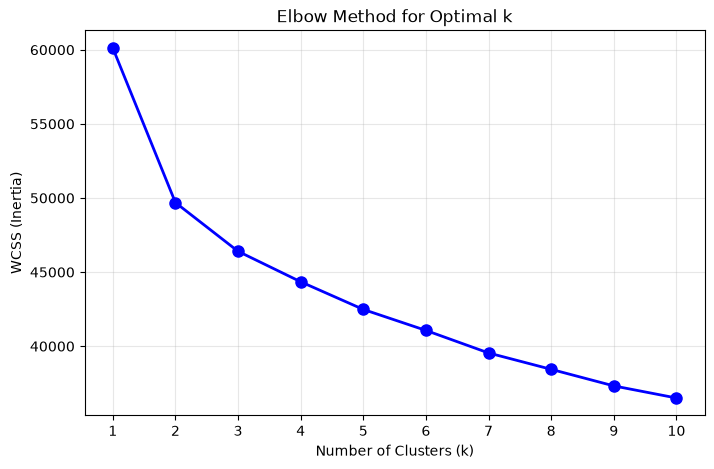

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Calculate WCSS (Within-Cluster Sum of Squares) for different k values
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.show()


# Test 2 groupen

In [95]:
X_scaled

array([[-0.36214263,  1.10754985, -0.66072622, ..., -0.97247066,
        -1.10539708, -0.32204821],
       [-0.36214263,  1.10754985,  1.51348617, ...,  0.16792722,
        -1.10539708, -1.65365181],
       [-0.36214263,  1.10754985, -0.66072622, ...,  0.30113774,
         1.75716029,  0.41587208],
       ...,
       [-0.36214263,  1.10754985,  1.51348617, ..., -0.97826242,
        -1.10539708,  0.18757093],
       [-0.36214263,  1.10754985,  1.51348617, ..., -0.93714092,
        -1.10539708, -1.33083403],
       [-0.36214263, -0.9028939 , -0.66072622, ..., -1.02227981,
         0.8029745 ,  0.02376026]], shape=(3340, 18))

In [105]:
df_raw

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,state,num_session,...,average_checked_bags,average_seat_price,weekend_trip_ratio,average_nights,total_flight_cost,total_hotels_cost,conversion_rate,age_group,total_spent,group
0,94883,F,True,False,usa,kansas city,MCI,51,Missouri,8,...,0.500000,276.252500,0.500000,1.000000,864.0900,230.0,0.250,50-59,1728.180,1
1,101486,F,True,True,usa,tacoma,TCM,50,Washington,8,...,0.000000,189.910000,1.000000,4.000000,189.9100,2199.0,0.250,50-59,379.820,1
2,101961,F,True,False,usa,boston,BOS,43,Massachusetts,8,...,0.400000,248.532000,0.200000,3.800000,1237.6930,2429.0,0.625,40-49,2475.386,0
5,149058,F,False,True,usa,birmingham,BHM,50,Alabama,8,...,0.400000,336.316000,0.200000,5.200000,1919.1325,5579.0,0.625,50-59,3838.265,0
6,153982,F,False,True,canada,toronto,YKZ,45,Ontario,8,...,0.333333,218.956667,0.000000,1.333333,656.8700,681.0,0.375,40-49,1313.740,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5988,760793,F,True,False,usa,modesto,MOD,40,California,8,...,0.500000,412.630000,0.333333,4.666667,825.2600,2664.0,0.375,40-49,1650.520,1
5991,774666,F,True,False,usa,minneapolis,MSP,44,Minnesota,8,...,1.500000,316.845000,0.000000,5.000000,633.6900,585.0,0.250,40-49,1267.380,1
5993,780167,F,True,True,usa,los angeles,LAX,49,California,8,...,0.000000,448.535000,0.000000,1.000000,1122.1060,220.0,0.250,40-49,2244.212,1
5994,785186,F,True,True,usa,little rock,LIT,44,Arkansas,8,...,0.000000,176.675000,1.000000,1.000000,353.3500,291.0,0.250,40-49,706.700,1


In [106]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit_predict(X_scaled)

array([2, 1, 0, ..., 2, 1, 2], shape=(3340,), dtype=int32)

In [107]:
df_raw["group"] =  kmeans.fit_predict(X_scaled)

In [108]:
df_raw["group"].value_counts()

group
1    1249
0    1135
2     956
Name: count, dtype: int64

/tmp/ipykernel_40948/3390656894.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="group", y=col, palette='Set2', legend=False)


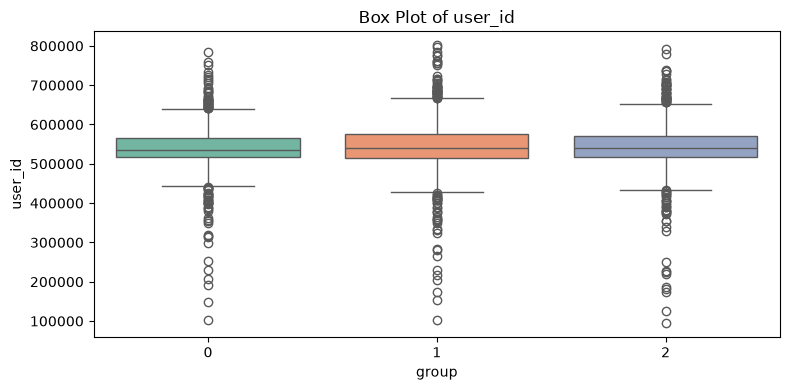

/tmp/ipykernel_40948/3390656894.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="group", y=col, palette='Set2', legend=False)


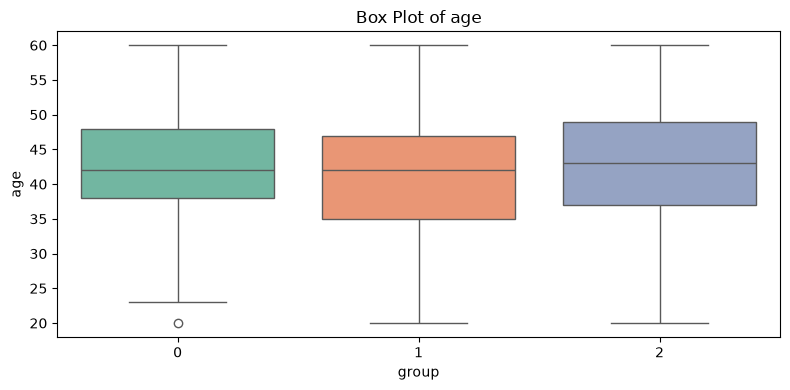

/tmp/ipykernel_40948/3390656894.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="group", y=col, palette='Set2', legend=False)


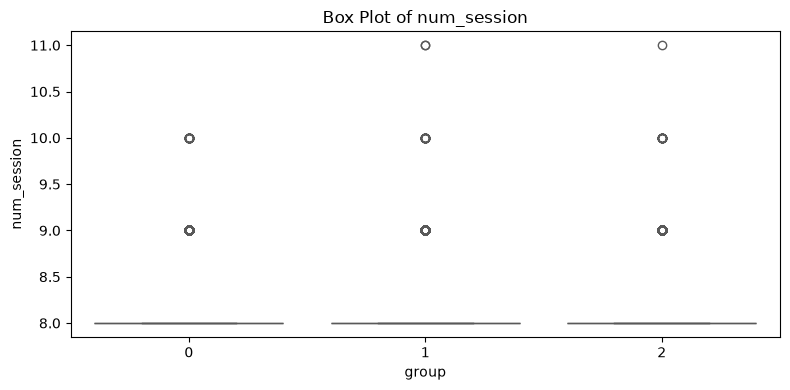

/tmp/ipykernel_40948/3390656894.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="group", y=col, palette='Set2', legend=False)


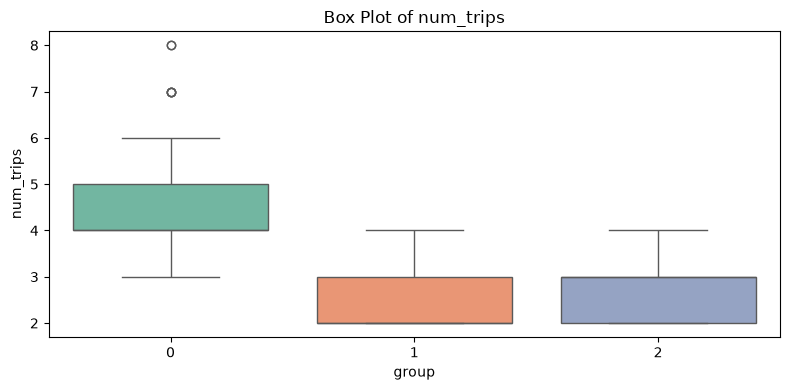

/tmp/ipykernel_40948/3390656894.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="group", y=col, palette='Set2', legend=False)


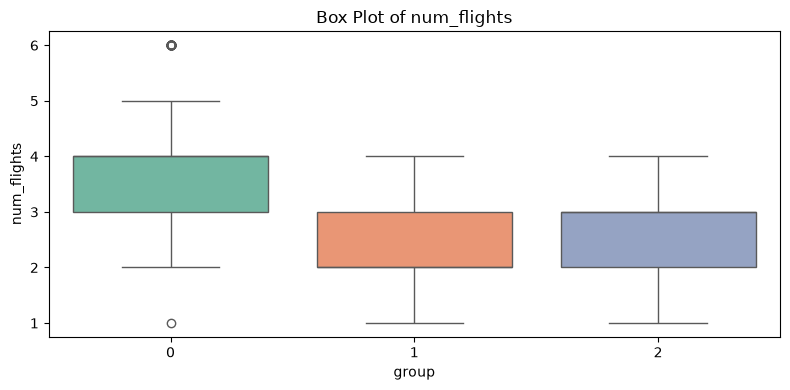

/tmp/ipykernel_40948/3390656894.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="group", y=col, palette='Set2', legend=False)


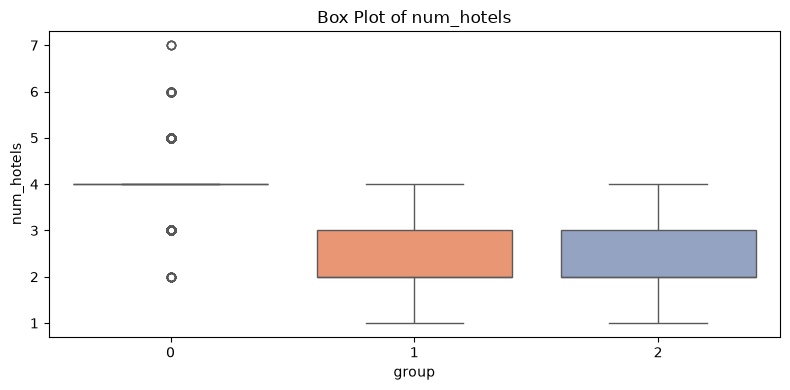

/tmp/ipykernel_40948/3390656894.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="group", y=col, palette='Set2', legend=False)


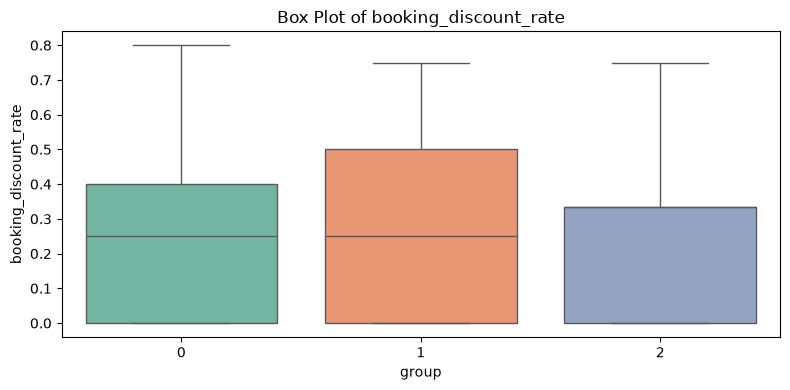

/tmp/ipykernel_40948/3390656894.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="group", y=col, palette='Set2', legend=False)


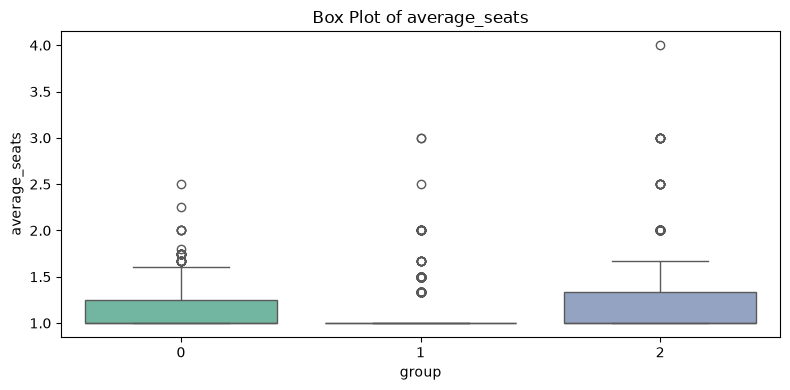

/tmp/ipykernel_40948/3390656894.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="group", y=col, palette='Set2', legend=False)


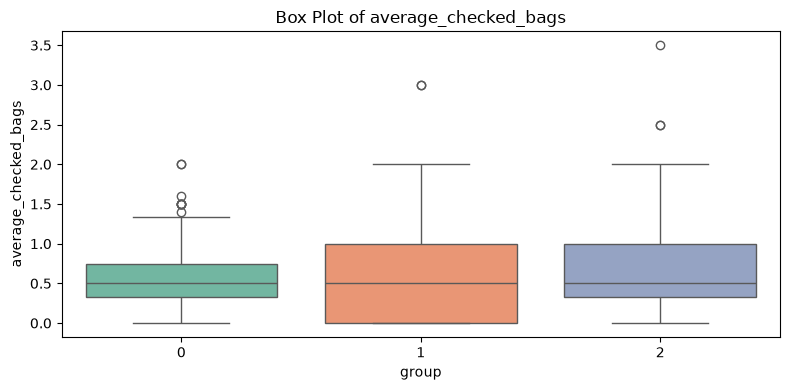

/tmp/ipykernel_40948/3390656894.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="group", y=col, palette='Set2', legend=False)


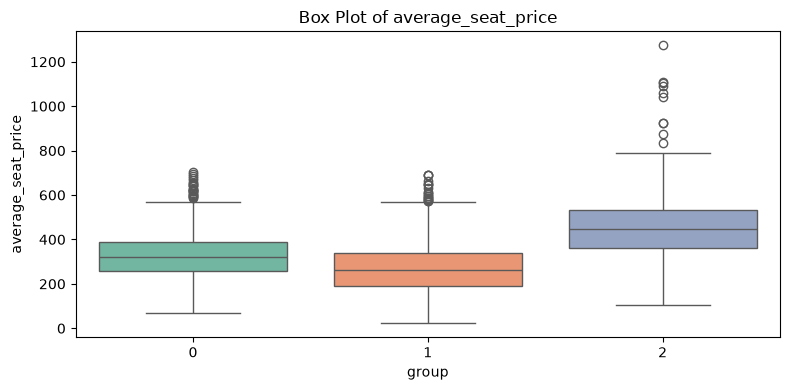

/tmp/ipykernel_40948/3390656894.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="group", y=col, palette='Set2', legend=False)


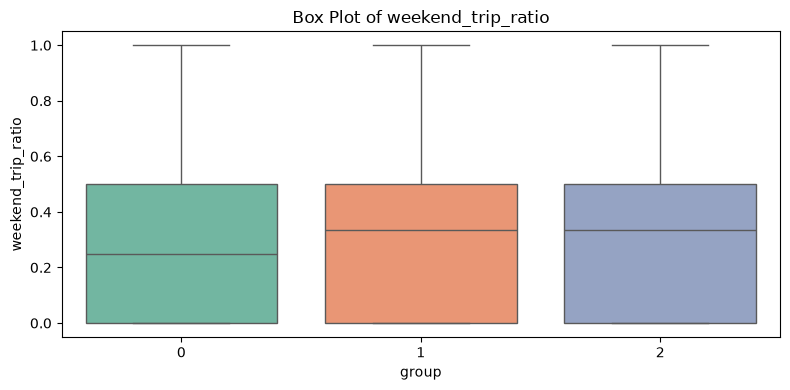

/tmp/ipykernel_40948/3390656894.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="group", y=col, palette='Set2', legend=False)


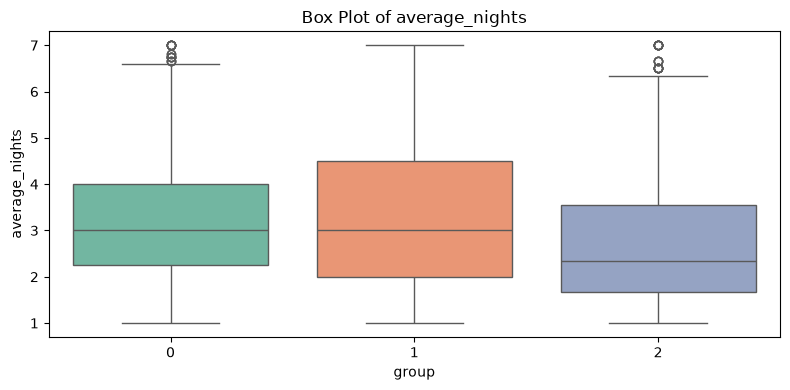

/tmp/ipykernel_40948/3390656894.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="group", y=col, palette='Set2', legend=False)


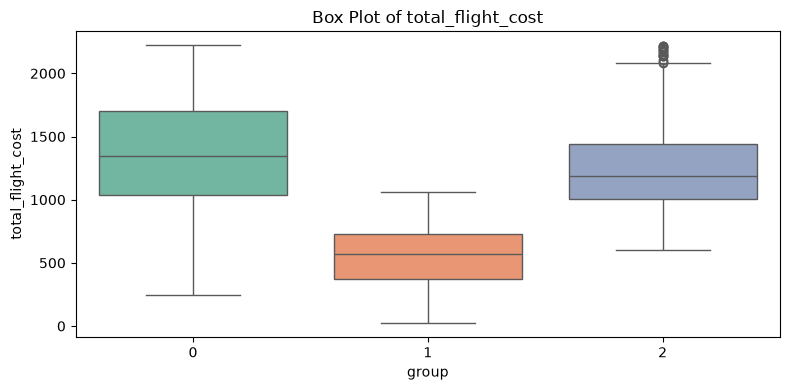

/tmp/ipykernel_40948/3390656894.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="group", y=col, palette='Set2', legend=False)


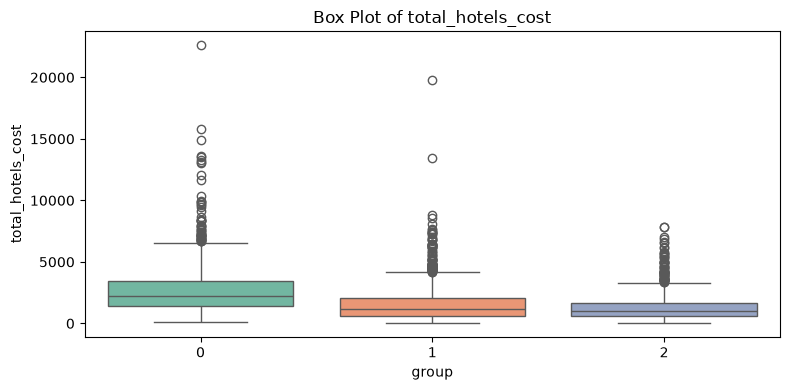

/tmp/ipykernel_40948/3390656894.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="group", y=col, palette='Set2', legend=False)


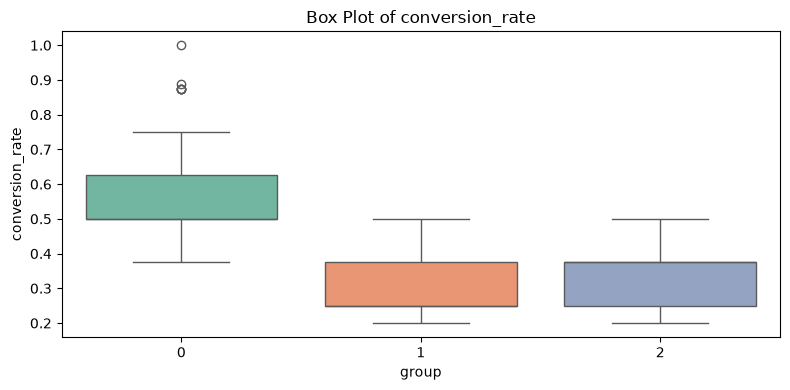

/tmp/ipykernel_40948/3390656894.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="group", y=col, palette='Set2', legend=False)


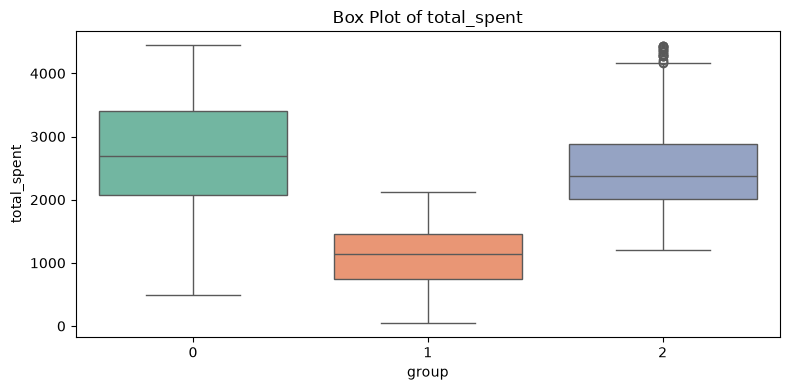

/tmp/ipykernel_40948/3390656894.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="group", y=col, palette='Set2', legend=False)


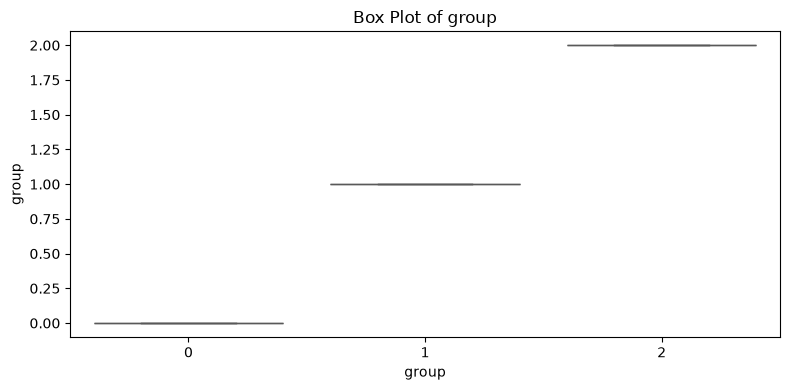

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Pick your numerical columns and grouping column
num_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
group_col = 'cluster'  # <-- your hue column (e.g., 'cluster', 'label', 'target')

# Loop and plot
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_raw, x="group", y=col, palette='Set2', legend=False)
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [111]:
df_raw["group"] = df_raw["group"].map({0:"Frequent Travelers", 1:"Budget Travelers", 2:"Comfort Travelers"})

In [112]:
df_raw

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,state,num_session,...,average_checked_bags,average_seat_price,weekend_trip_ratio,average_nights,total_flight_cost,total_hotels_cost,conversion_rate,age_group,total_spent,group
0,94883,F,True,False,usa,kansas city,MCI,51,Missouri,8,...,0.500000,276.252500,0.500000,1.000000,864.0900,230.0,0.250,50-59,1728.180,Comfort Travelers
1,101486,F,True,True,usa,tacoma,TCM,50,Washington,8,...,0.000000,189.910000,1.000000,4.000000,189.9100,2199.0,0.250,50-59,379.820,Budget Travelers
2,101961,F,True,False,usa,boston,BOS,43,Massachusetts,8,...,0.400000,248.532000,0.200000,3.800000,1237.6930,2429.0,0.625,40-49,2475.386,Frequent Travelers
5,149058,F,False,True,usa,birmingham,BHM,50,Alabama,8,...,0.400000,336.316000,0.200000,5.200000,1919.1325,5579.0,0.625,50-59,3838.265,Frequent Travelers
6,153982,F,False,True,canada,toronto,YKZ,45,Ontario,8,...,0.333333,218.956667,0.000000,1.333333,656.8700,681.0,0.375,40-49,1313.740,Budget Travelers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5988,760793,F,True,False,usa,modesto,MOD,40,California,8,...,0.500000,412.630000,0.333333,4.666667,825.2600,2664.0,0.375,40-49,1650.520,Budget Travelers
5991,774666,F,True,False,usa,minneapolis,MSP,44,Minnesota,8,...,1.500000,316.845000,0.000000,5.000000,633.6900,585.0,0.250,40-49,1267.380,Budget Travelers
5993,780167,F,True,True,usa,los angeles,LAX,49,California,8,...,0.000000,448.535000,0.000000,1.000000,1122.1060,220.0,0.250,40-49,2244.212,Comfort Travelers
5994,785186,F,True,True,usa,little rock,LIT,44,Arkansas,8,...,0.000000,176.675000,1.000000,1.000000,353.3500,291.0,0.250,40-49,706.700,Budget Travelers


In [118]:
df_final = pd.concat([user_features[user_features["group"]!="Not assigned"],df_raw])

# Df_final Analysis

In [120]:
df_final["group"].value_counts()

group
Indecisive            1373
Budget Travelers      1249
Frequent Travelers    1135
Comfort Travelers      956
Long Stayers           481
High Spenders          476
Discount buyer         102
Family travelers        76
Retired                 63
Youngs                  52
Only Hotel              25
Only Flight             10
Name: count, dtype: int64

In [124]:
df_final[["user_id", "group"]].to_csv("data/final_groups.csv", index=False)